In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

In [2]:
df = pd.read_csv('../data/Sample - Superstore.csv', encoding='latin-1')

print("✅ Dataset Loaded")
print("Shape:", df.shape)
df.head()

✅ Dataset Loaded
Shape: (9994, 21)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.00,41.91
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.00,219.58
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.00,6.87
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.58,5,0.45,-383.03
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.37,2,0.20,2.52


In [3]:
print("Columns:\n", df.columns.tolist())
print("\nData Types:\n", df.dtypes)

Columns:
 ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']

Data Types:
 Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code        int64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object


In [4]:
print("Missing Values:\n")
print(df.isnull().sum())

Missing Values:

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


In [5]:
print("Sales Statistics:\n")
print(df['Sales'].describe())
print("\nProfit Statistics:\n")
print(df['Profit'].describe())

Sales Statistics:

count    9994.00
mean      229.86
std       623.25
min         0.44
25%        17.28
50%        54.49
75%       209.94
max     22638.48
Name: Sales, dtype: float64

Profit Statistics:

count    9994.00
mean       28.66
std       234.26
min     -6599.98
25%         1.73
50%         8.67
75%        29.36
max      8399.98
Name: Profit, dtype: float64


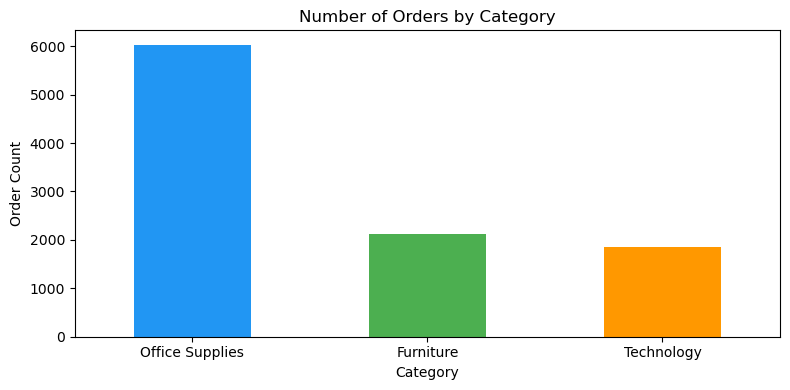

In [6]:
plt.figure(figsize=(8,4))
df['Category'].value_counts().plot(kind='bar', color=['#2196F3','#4CAF50','#FF9800'])
plt.title('Number of Orders by Category')
plt.xlabel('Category')
plt.ylabel('Order Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

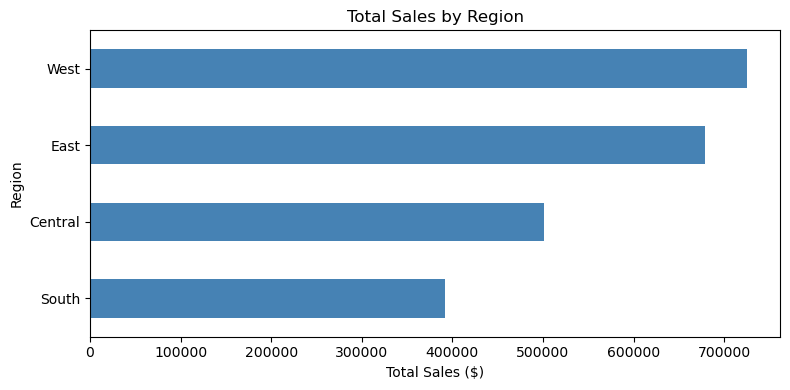

In [7]:
plt.figure(figsize=(8,4))
df.groupby('Region')['Sales'].sum().sort_values().plot(kind='barh', color='steelblue')
plt.title('Total Sales by Region')
plt.xlabel('Total Sales ($)')
plt.tight_layout()
plt.show()

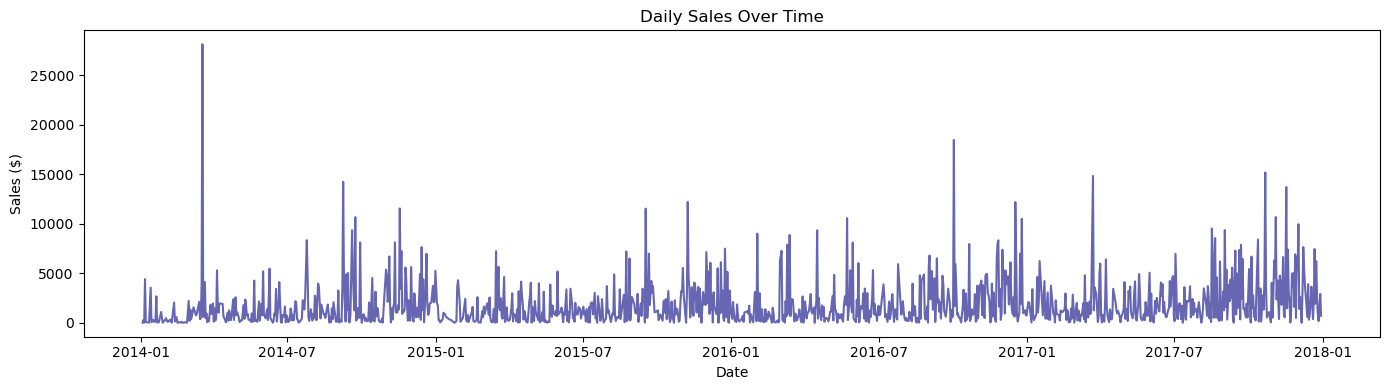

In [8]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df_time = df.groupby('Order Date')['Sales'].sum().reset_index()

plt.figure(figsize=(14,4))
plt.plot(df_time['Order Date'], df_time['Sales'], alpha=0.6, color='navy')
plt.title('Daily Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Sales ($)')
plt.tight_layout()
plt.show()